In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import date

#Import Model Packages
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from sklearn.metrics import adjusted_mutual_info_score
from sklearn import cluster, covariance, manifold

# Package for mean variance optimization
from scipy.optimize import minimize


In [2]:
dataset = read_csv('selected_stocks_prices.csv', index_col=0)

In [3]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
type(dataset)

pandas.core.frame.DataFrame

#3.Exploratory Data Analysis




#3.1. Descriptive Statistics

In [5]:
# shape
dataset.shape

(1236, 12)

In [6]:
# peek at data
set_option('display.width', 100)
dataset.head()

,ADANIPORTS.NS,COALINDIA.NS,DRREDDY.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,MARUTI.NS,MUTHOOTFIN.NS,ONGC.NS,RELIANCE.NS,TCS.NS
Date,,,,,,,,,,,,
2021-01-01,489.095947,87.478416,1015.833679,674.886414,510.191437,1109.599854,164.067825,7371.631836,1119.133301,68.642113,901.194641,2569.267822
2021-01-04,484.290894,88.706421,1021.822205,670.600403,514.253662,1134.072510,163.722580,7382.174805,1147.541748,71.403999,902.713684,2666.835205
2021-01-05,484.824768,87.349167,1024.661621,675.667725,519.621521,1138.958618,162.226517,7337.271973,1192.229492,69.931000,891.491211,2713.821289
2021-01-06,482.252350,87.316841,1024.933105,672.755249,528.761475,1128.658691,157.584915,7311.538086,1181.438110,71.403999,867.980774,2677.408203
2021-01-07,498.803101,88.221687,1021.560608,670.718811,523.345215,1111.096191,155.590149,7251.586914,1178.255981,72.103676,866.575134,2661.000977


## 3.2. Data Visualization

## 4. Data Preparation

## 4.1. Data Cleaning
We check for the NAs in the rows, either drop them or fill them with the mean of the column.

In [7]:
#Checking for any null values and removing the null values'''
print('Null Values =',dataset.isnull().values.any())
dataset.shape

Null Values = False


(1236, 12)

Getting rid of the columns with more than 30% missing values.

In [8]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

drop_list = sorted(list(missing_fractions[missing_fractions > 0.4].index))

dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(1236, 12)

Given that there are null values drop the rown contianing the null values.

In [9]:
# Fill the missing values with the last value available in the dataset.
dataset=dataset.fillna(method='ffill')
dataset.head()

,ADANIPORTS.NS,COALINDIA.NS,DRREDDY.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,MARUTI.NS,MUTHOOTFIN.NS,ONGC.NS,RELIANCE.NS,TCS.NS
Date,,,,,,,,,,,,
2021-01-01,489.095947,87.478416,1015.833679,674.886414,510.191437,1109.599854,164.067825,7371.631836,1119.133301,68.642113,901.194641,2569.267822
2021-01-04,484.290894,88.706421,1021.822205,670.600403,514.253662,1134.072510,163.722580,7382.174805,1147.541748,71.403999,902.713684,2666.835205
2021-01-05,484.824768,87.349167,1024.661621,675.667725,519.621521,1138.958618,162.226517,7337.271973,1192.229492,69.931000,891.491211,2713.821289
2021-01-06,482.252350,87.316841,1024.933105,672.755249,528.761475,1128.658691,157.584915,7311.538086,1181.438110,71.403999,867.980774,2677.408203
2021-01-07,498.803101,88.221687,1021.560608,670.718811,523.345215,1111.096191,155.590149,7251.586914,1178.255981,72.103676,866.575134,2661.000977


## 4.2. Data Transformation

For the purpose of clustering, we will be using annual
returns. Additionally, we will train the data followed by testing. Let us prepare the
dataset for training and testing, by separating 20% of the dataset for testing followed
by generating the return series.

In [10]:
X= dataset.copy('deep')
row= len(X)
# train_len = int(row*.8)
train_len = int(row*.8335)

In [11]:
X_train = X.head(train_len)

In [12]:
X_train

,ADANIPORTS.NS,COALINDIA.NS,DRREDDY.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,MARUTI.NS,MUTHOOTFIN.NS,ONGC.NS,RELIANCE.NS,TCS.NS
Date,,,,,,,,,,,,
2021-01-01,489.095947,87.478416,1015.833679,674.886414,510.191437,1109.599854,164.067825,7371.631836,1119.133301,68.642113,901.194641,2569.267822
2021-01-04,484.290894,88.706421,1021.822205,670.600403,514.253662,1134.072510,163.722580,7382.174805,1147.541748,71.403999,902.713684,2666.835205
2021-01-05,484.824768,87.349167,1024.661621,675.667725,519.621521,1138.958618,162.226517,7337.271973,1192.229492,69.931000,891.491211,2713.821289
2021-01-06,482.252350,87.316841,1024.933105,672.755249,528.761475,1128.658691,157.584915,7311.538086,1181.438110,71.403999,867.980774,2677.408203
2021-01-07,498.803101,88.221687,1021.560608,670.718811,523.345215,1111.096191,155.590149,7251.586914,1178.255981,72.103676,866.575134,2661.000977
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-21,1078.005249,350.218506,1144.541260,834.963806,1223.509277,1762.830200,385.566467,12191.497070,2185.355469,232.937576,1223.264404,3659.529785
2025-02-24,1065.217529,345.343170,1157.210815,827.366516,1209.021118,1713.393188,386.528198,12213.013672,2162.090088,227.548660,1209.718506,3552.817627
2025-02-25,1075.119385,341.887848,1121.040283,829.956482,1214.776733,1716.889771,389.365387,12342.758789,2156.854004,226.237823,1199.210449,3508.305908


In [13]:
X_test = X.tail(row-train_len)

In [14]:
#Calculate percentage return
returns = X_train.pct_change().dropna()
returns_test=X_test.pct_change().dropna()

The parameters to clusters are the indices and the variables used in the clustering are the columns. Hence the data is in the right format to be fed to the clustering algorithms

# 5. Evaluate Algorithms and Models

## 5.1. Building Hierarchy Graph/ Dendogram

The first step is to look for clusters of corre‐
lations using the agglomerate hierarchical clustering technique. The hierarchy class
has a dendrogram method which takes the value returned by the linkage method of
the same class.

Linkage does the actual clustering in one line of code, and returns a list of the clusters joined in the format: Z=[stock_1, stock_2, distance, sample_count]

#### Compute Correlation

In [15]:
def correlDist(corr):
    # A distance matrix based on correlation, where 0<=d[i,j]<=1
    # This is a proper distance metric
    dist = ((1 - corr) / 2.)**.5  # distance matrix
    return dist

In [16]:
#Calulate linkage
dist = correlDist(returns.corr())
link = linkage(dist, 'ward')
link[0]

array([ 5.        , 11.        ,  0.55572396,  2.        ])

Computation of linkages is followed by
the visualization of the clusters through a dendrogram, which displays a cluster tree.
The leaves are the individual stocks and the root is the final single cluster. The “distance” between each cluster is shown on the y-axis, and thus the longer the branches
are, the less correlated two clusters are.

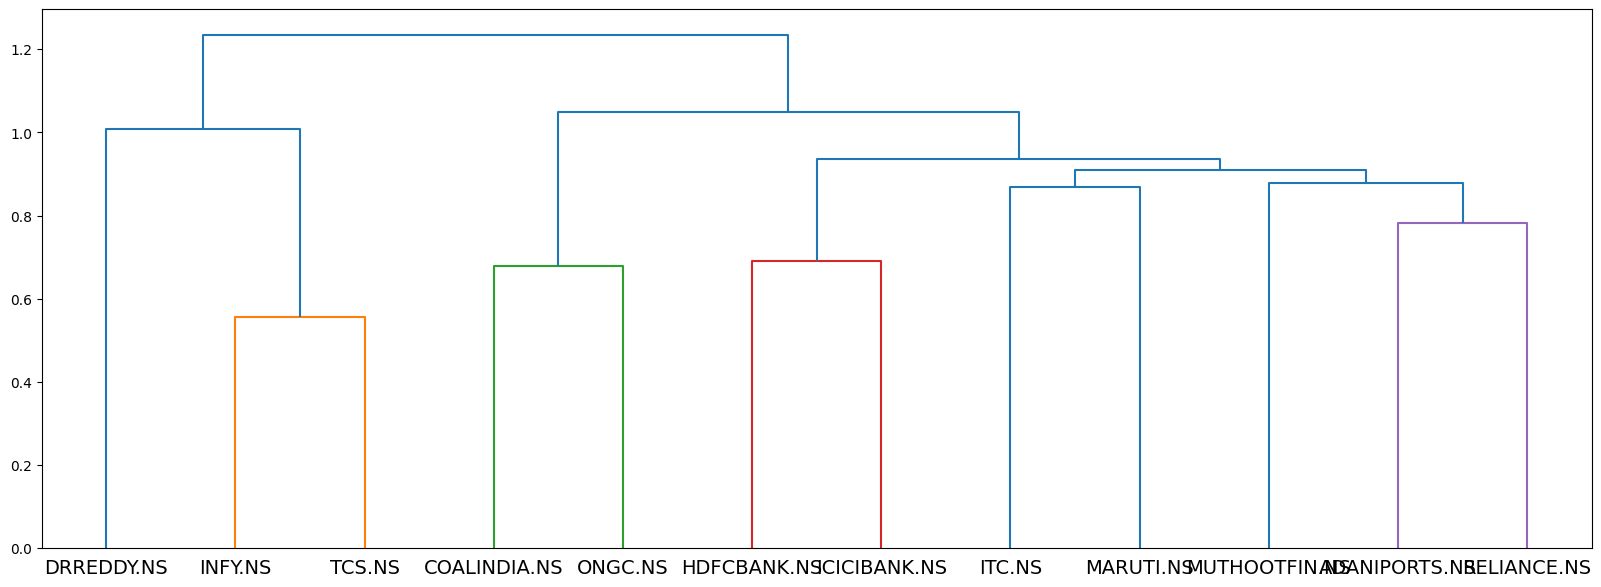

In [17]:
#Plot Dendogram
plt.figure(figsize=(20, 7))
#plt.title("Dendrograms")
dendrogram(link,labels = X.columns, leaf_font_size=14)
plt.show()

## 5.2 Steps for Hierarchial Risk Parity

#### Quasi-diagonalization and getting the weights for Hierarchial Risk Parity

A 'quasi-diagonalization' is a process usually known as matrix seriation and which can be performed using hierarchical clustering.
This process reorganize the covariance matrix so similar investments will be placed together. This matrix diagonalization allow us to distribute weights optimally following an inverse-variance allocation.

In [18]:
def getQuasiDiag(link):
    # Sort clustered items by distance
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]  # number of original items
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)  # make space
        df0 = sortIx[sortIx >= numItems]  # find clusters
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]  # item 1
        df0 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df0])  # item 2
        sortIx = sortIx.sort_index()  # re-sort
        sortIx.index = range(sortIx.shape[0])  # re-index
    return sortIx.tolist()

#### Recursive bisection

 This step distributes the allocation through recursive bisection based on cluster covariance.

In [19]:
def getClusterVar(cov,cItems):
    # Compute variance per cluster
    cov_=cov.loc[cItems,cItems] # matrix slice
    w_=getIVP(cov_).reshape(-1,1)
    cVar=np.dot(np.dot(w_.T,cov_),w_)[0,0]
    return cVar



def getRecBipart(cov, sortIx):
    # Compute HRP alloc
    w = pd.Series(1, index=sortIx)
    cItems = [sortIx]  # initialize all items in one cluster
    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]  # bi-section
        for i in range(0, len(cItems), 2):  # parse in pairs
            cItems0 = cItems[i]  # cluster 1
            cItems1 = cItems[i + 1]  # cluster 2
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1 - cVar0 / (cVar0 + cVar1)
            w[cItems0] *= alpha  # weight 1
            w[cItems1] *= 1 - alpha  # weight 2
    return w

#### Comparison against other asset allocation methods:.

The main premise of this case study
was to develop an alternative to Markowitz’s Minimum-Variance Portfolio based
asset allocation. So, in this step, we define a functions to compare the performance of the following asset allocation methods.

    1. MVP - Markowitz’s Minimum-Variance Portfolio
    2. HRP - Hierarchial Risk Parity
    3. Eigen - Portfolio

# MVP

In [20]:
def getMVP(cov):

    cov = cov.T.values
    n = len(cov)
    N = 100
    mus = [10 ** (5.0 * t / N - 1.0) for t in range(N)]

    # Convert to cvxopt matrices
    S = opt.matrix(cov)
    #pbar = opt.matrix(np.mean(returns, axis=1))
    pbar = opt.matrix(np.ones(cov.shape[0]))

    # Create constraint matrices
    G = -opt.matrix(np.eye(n))  # negative n x n identity matrix
    h = opt.matrix(0.0, (n, 1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)


    # Calculate efficient frontier weights using quadratic programming
    solvers.options['show_progress'] = False
    portfolios = [solvers.qp(mu * S, -pbar, G, h, A, b)['x']
                  for mu in mus]
    ## CALCULATE RISKS AND RETURNS FOR FRONTIER
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S * x)) for x in portfolios]
    ## CALCULATE THE 2ND DEGREE POLYNOMIAL OF THE FRONTIER CURVE
    m1 = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    # CALCULATE THE OPTIMAL PORTFOLIO
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']

    return list(wt)

def getIVP(cov, **kargs):
    # Compute the inverse-variance portfolio
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def getHRP(cov, corr):
    # Construct a hierarchical portfolio
    dist = correlDist(corr)
    link = sch.linkage(dist, 'single')
    #plt.figure(figsize=(20, 10))
    #dn = sch.dendrogram(link, labels=cov.index.values)
    #plt.show()
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    hrp = getRecBipart(cov, sortIx)
    return hrp.sort_index()

Eigen Portfolio

In [21]:
# Step 1: Define Eigen Portfolio function
from numpy.linalg import eigh

def getEigenPortfolio(cov):

    cov_matrix = cov.values

    # Compute eigenvalues and eigenvectors (eigh for symmetric matrices)
    eigenvalues, eigenvectors = eigh(cov_matrix)

    # Sort by descending eigenvalue (largest first)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]

    # Take the dominant eigenvector (largest eigenvalue)
    vec = eigenvectors[:, 0]

    # Normalize to long-only weights summing to 1
    weights = np.abs(vec) / np.abs(vec).sum()

    return pd.Series(weights, index=cov.index)

In [22]:
from scipy.optimize import minimize

def getMVP(cov):
    n = cov.shape[0]
    cov_matrix = cov.values  # convert DataFrame to numpy array

    def portfolio_variance(weights):
        return weights.T @ cov_matrix @ weights

    # Constraints: weights sum to 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    # Bounds: each weight between 0 and 1 (long only)
    bounds = tuple((0, 1) for _ in range(n))

    # Initial guess: equal weights
    w0 = np.ones(n) / n

    result = minimize(
        portfolio_variance,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    weights = result.x
    return weights / weights.sum()  # normalize to ensure sum = 1


def get_all_portfolios(returns):
    cov, corr = returns.cov(), returns.corr()
    hrp = getHRP(cov, corr)
    mvp = getMVP(cov)
    mvp = pd.Series(mvp, index=cov.index)
    eigen = getEigenPortfolio(cov)
    portfolios = pd.DataFrame([mvp, hrp, eigen], index=['MVP', 'HRP', 'Eigen']).T
    return portfolios


portfolios = get_all_portfolios(returns)
print(portfolios)

                        MVP       HRP     Eigen
ADANIPORTS.NS  0.000000e+00  0.024573  0.187056
COALINDIA.NS   3.621913e-18  0.035911  0.126040
DRREDDY.NS     2.064553e-01  0.140386  0.035139
HDFCBANK.NS    1.145056e-01  0.105046  0.064733
ICICIBANK.NS   7.345229e-02  0.075818  0.071228
INFY.NS        1.179705e-02  0.071072  0.056580
ITC.NS         1.935569e-01  0.156884  0.049923
MARUTI.NS      1.058053e-01  0.099948  0.061912
MUTHOOTFIN.NS  5.100314e-02  0.068608  0.087207
ONGC.NS        4.451574e-02  0.030955  0.123054
RELIANCE.NS    2.541518e-02  0.099226  0.086950
TCS.NS         1.734935e-01  0.091572  0.050179


Text(0.5, 1.0, 'Eigen Portfolio')

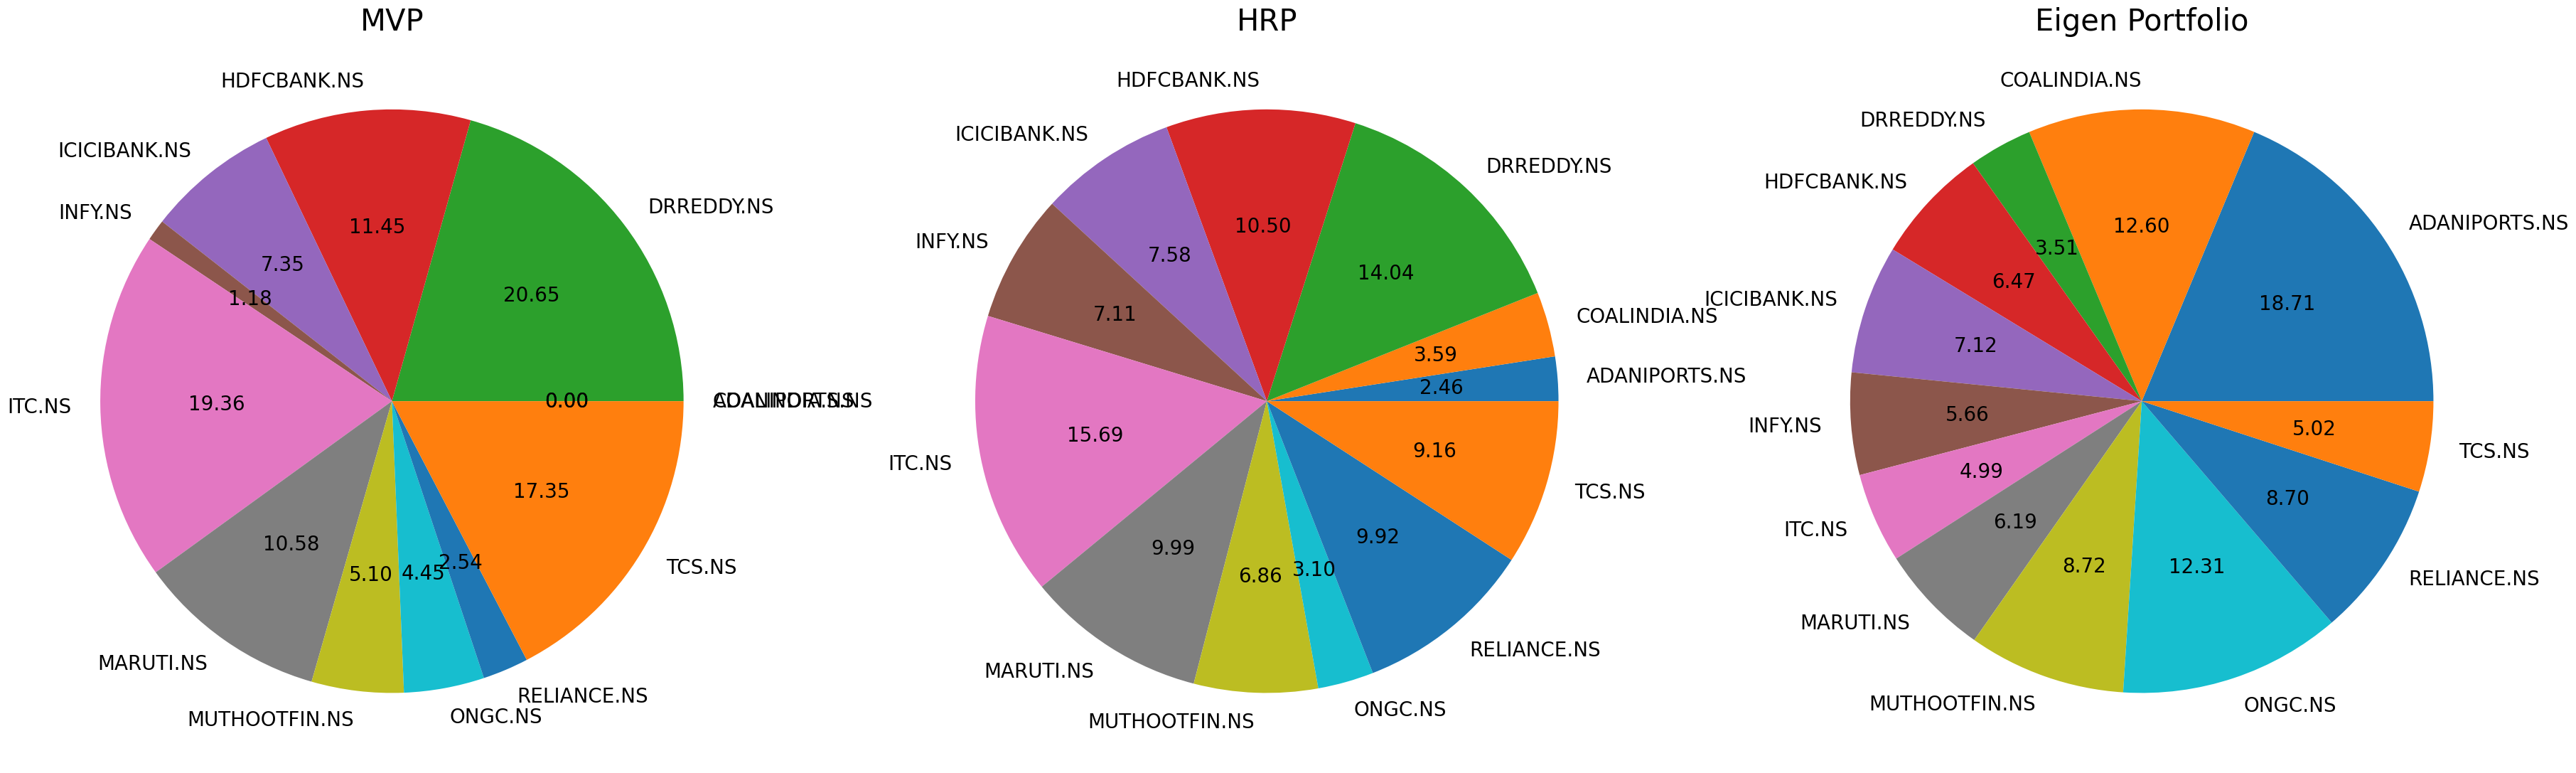

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(45, 20))
ax1.pie(portfolios.iloc[:,0], labels=portfolios.index, autopct='%.2f', textprops={'fontsize': 20})
ax1.set_title('MVP', fontsize=30)
ax2.pie(portfolios.iloc[:,1], labels=portfolios.index, autopct='%.2f', textprops={'fontsize': 20})
ax2.set_title('HRP', fontsize=30)
ax3.pie(portfolios.iloc[:,2], labels=portfolios.index, autopct='%.2f', textprops={'fontsize': 20})
ax3.set_title('Eigen Portfolio', fontsize=30)

In [24]:
# MVP Weights
portfolios.iloc[:,0]

ADANIPORTS.NS    0.000000e+00
COALINDIA.NS     3.621913e-18
DRREDDY.NS       2.064553e-01
HDFCBANK.NS      1.145056e-01
ICICIBANK.NS     7.345229e-02
INFY.NS          1.179705e-02
ITC.NS           1.935569e-01
MARUTI.NS        1.058053e-01
MUTHOOTFIN.NS    5.100314e-02
ONGC.NS          4.451574e-02
RELIANCE.NS      2.541518e-02
TCS.NS           1.734935e-01
Name: MVP, dtype: float64

In [25]:
# HRP Weights
portfolios.iloc[:,1]

ADANIPORTS.NS    0.024573
COALINDIA.NS     0.035911
DRREDDY.NS       0.140386
HDFCBANK.NS      0.105046
ICICIBANK.NS     0.075818
INFY.NS          0.071072
ITC.NS           0.156884
MARUTI.NS        0.099948
MUTHOOTFIN.NS    0.068608
ONGC.NS          0.030955
RELIANCE.NS      0.099226
TCS.NS           0.091572
Name: HRP, dtype: float64

In [26]:
# Eigen Portfolio Weights
portfolios.iloc[:,2]

ADANIPORTS.NS    0.187056
COALINDIA.NS     0.126040
DRREDDY.NS       0.035139
HDFCBANK.NS      0.064733
ICICIBANK.NS     0.071228
INFY.NS          0.056580
ITC.NS           0.049923
MARUTI.NS        0.061912
MUTHOOTFIN.NS    0.087207
ONGC.NS          0.123054
RELIANCE.NS      0.086950
TCS.NS           0.050179
Name: Eigen, dtype: float64

In [27]:
Insample_Result = pd.DataFrame(np.dot(returns, np.array(portfolios)),
                                columns=['MVP', 'HRP', 'Eigen'], index=returns.index)

OutOfSample_Result = pd.DataFrame(np.dot(returns_test, np.array(portfolios)),
                                   columns=['MVP', 'HRP', 'Eigen'], index=returns_test.index)

<Axes: xlabel='Date', ylabel='Return'>

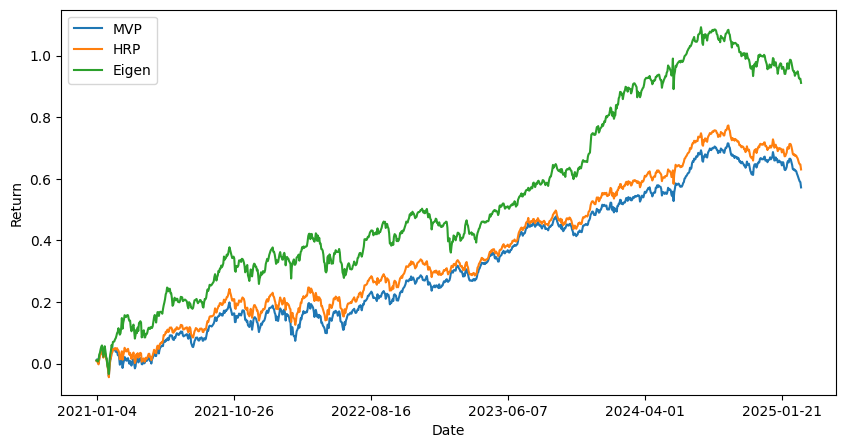

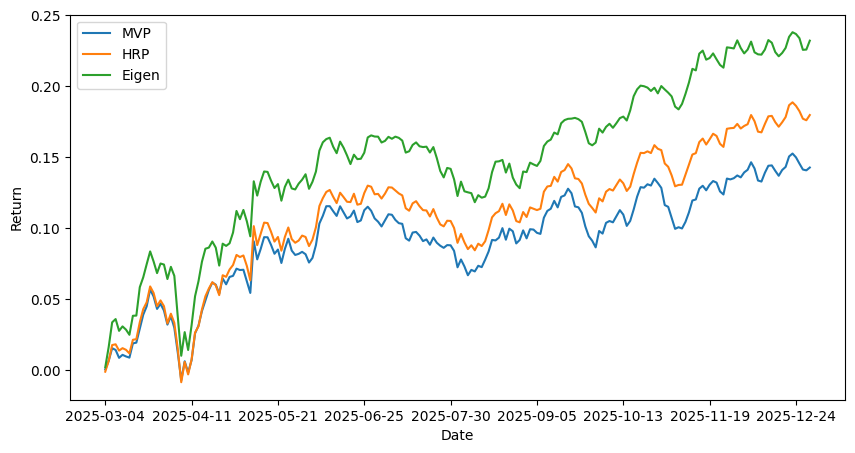

In [28]:
Insample_Result.cumsum().plot(figsize=(10, 5), ylabel="Return")
OutOfSample_Result.cumsum().plot(figsize=(10, 5), ylabel="Return")

In [29]:
ret_insample = Insample_Result.mean() * 252
ret_insample

MVP      0.140107
HRP      0.154380
Eigen    0.223162
dtype: float64

In [30]:
ret_out_of_sample = OutOfSample_Result.mean() * 252
ret_out_of_sample

MVP      0.175406
HRP      0.220924
Eigen    0.285383
dtype: float64

In [31]:
rf = 0.05  # annual risk-free rate
rf_daily = rf / 252

stddev = Insample_Result.std() * np.sqrt(252)

sharp_ratio = ((Insample_Result.mean() - rf_daily) / Insample_Result.std()) * np.sqrt(252)

Results = pd.DataFrame(dict(stdev=stddev, sharp_ratio=sharp_ratio))
Results

,stdev,sharp_ratio
MVP,0.128091,0.703461
HRP,0.133158,0.783881
Eigen,0.179000,0.967390


In [32]:
rf = 0.05  # annual risk-free rate
rf_daily = rf / 252

stddev_oos = OutOfSample_Result.std() * np.sqrt(252)

sharp_ratio_oos = ((OutOfSample_Result.mean() - rf_daily) / OutOfSample_Result.std()) * np.sqrt(252)

Results_oos = pd.DataFrame(dict(stdev_oos=stddev_oos, sharp_ratio_oos=sharp_ratio_oos))

Results_oos

,stdev_oos,sharp_ratio_oos
MVP,0.104513,1.199906
HRP,0.107367,1.591960
Eigen,0.122136,1.927224


In [33]:
from scipy.stats import norm

def jobson_korkie_test(r1, r2, rf=0.06):

    r1 = r1 - rf/252
    r2 = r2 - rf/252

    T = len(r1)

    mean1, mean2 = np.mean(r1), np.mean(r2)
    std1, std2 = np.std(r1), np.std(r2)
    corr = np.corrcoef(r1, r2)[0,1]

    sr1 = mean1/std1
    sr2 = mean2/std2

    numerator = sr1 - sr2

    denominator = np.sqrt(
        (1/T) * (
            2*(1 - corr) +
            (sr1**2 + sr2**2 - 2*sr1*sr2*corr)
        )
    )

    z_stat = numerator / denominator
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    return z_stat, p_value

In [34]:
z, p = jobson_korkie_test(OutOfSample_Result['MVP'], OutOfSample_Result['HRP'])

print("MVP vs HRP")
print("Z-stat:", z)
print("P-value:", p)

MVP vs HRP
Z-stat: -1.8791899422202212
P-value: 0.060218562469626535


In [35]:
z, p = jobson_korkie_test(OutOfSample_Result['MVP'], OutOfSample_Result['Eigen'])

print("MVP vs Eigen")
print("Z-stat:", z)
print("P-value:", p)

MVP vs Eigen
Z-stat: -1.3351491734720378
P-value: 0.1818275280919237


In [36]:
z, p = jobson_korkie_test(OutOfSample_Result['HRP'], OutOfSample_Result['Eigen'])

print("HRP vs Eigen")
print("Z-stat:", z)
print("P-value:", p)

HRP vs Eigen
Z-stat: -0.8196025232178293
P-value: 0.41244273476527527


In [37]:
from sklearn.covariance import LedoitWolf

def ledoit_wolf_test(r1, r2, rf=0.06):

    r1 = r1 - rf/252
    r2 = r2 - rf/252

    T = len(r1)

    combined = np.column_stack([r1, r2])
    lw = LedoitWolf()
    lw.fit(combined)
    lw_cov = lw.covariance_

    mean1, mean2 = np.mean(r1), np.mean(r2)
    std1 = np.sqrt(lw_cov[0, 0])
    std2 = np.sqrt(lw_cov[1, 1])
    cov12 = lw_cov[0, 1]

    sr1 = mean1 / std1
    sr2 = mean2 / std2

    var_diff = (1/T) * (
        (std1**2 + std2**2 - 2*cov12) /
        (std1**2 * std2**2)
    )

    z_stat = (sr1 - sr2) / np.sqrt(var_diff)
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    return z_stat, p_value

In [38]:
z, p = ledoit_wolf_test(OutOfSample_Result['MVP'], OutOfSample_Result['HRP'])

print("Ledoit-Wolf: MVP vs HRP")
print("Z-stat:", z)
print("P-value:", p)

Ledoit-Wolf: MVP vs HRP
Z-stat: -0.006103036905592915
P-value: 0.9951305113080586


In [39]:
z, p = ledoit_wolf_test(OutOfSample_Result['MVP'], OutOfSample_Result['Eigen'])

print("Ledoit-Wolf: MVP vs Eigen")
print("Z-stat:", z)
print("P-value:", p)

Ledoit-Wolf: MVP vs Eigen
Z-stat: -0.00777669411812977
P-value: 0.9937951583707925


In [40]:
z, p = ledoit_wolf_test(OutOfSample_Result['HRP'], OutOfSample_Result['Eigen'])

print("Ledoit-Wolf: HRP vs Eigen")
print("Z-stat:", z)
print("P-value:", p)

Ledoit-Wolf: HRP vs Eigen
Z-stat: -0.004432868640140631
P-value: 0.9964630941355264


In [41]:
jk_z_mvp_hrp,   jk_p_mvp_hrp   = jobson_korkie_test(OutOfSample_Result['MVP'], OutOfSample_Result['HRP'])
jk_z_mvp_eigen, jk_p_mvp_eigen = jobson_korkie_test(OutOfSample_Result['MVP'], OutOfSample_Result['Eigen'])
jk_z_hrp_eigen, jk_p_hrp_eigen = jobson_korkie_test(OutOfSample_Result['HRP'], OutOfSample_Result['Eigen'])

lw_z_mvp_hrp,   lw_p_mvp_hrp   = ledoit_wolf_test(OutOfSample_Result['MVP'], OutOfSample_Result['HRP'])
lw_z_mvp_eigen, lw_p_mvp_eigen = ledoit_wolf_test(OutOfSample_Result['MVP'], OutOfSample_Result['Eigen'])
lw_z_hrp_eigen, lw_p_hrp_eigen = ledoit_wolf_test(OutOfSample_Result['HRP'], OutOfSample_Result['Eigen'])

results = pd.DataFrame({
    'Pair'            : ['MVP vs HRP', 'MVP vs Eigen', 'HRP vs Eigen'],
    'JK Z-Stat'       : [jk_z_mvp_hrp,   jk_z_mvp_eigen,   jk_z_hrp_eigen],
    'JK P-Value'      : [jk_p_mvp_hrp,   jk_p_mvp_eigen,   jk_p_hrp_eigen],
    'JK Significant'  : ['Yes' if p < 0.05 else 'No' for p in [jk_p_mvp_hrp, jk_p_mvp_eigen, jk_p_hrp_eigen]],
    'LW Z-Stat'       : [lw_z_mvp_hrp,   lw_z_mvp_eigen,   lw_z_hrp_eigen],
    'LW P-Value'      : [lw_p_mvp_hrp,   lw_p_mvp_eigen,   lw_p_hrp_eigen],
    'LW Significant'  : ['Yes' if p < 0.05 else 'No' for p in [lw_p_mvp_hrp, lw_p_mvp_eigen, lw_p_hrp_eigen]]
})

print(results)

           Pair  JK Z-Stat  JK P-Value JK Significant  LW Z-Stat  LW P-Value LW Significant
0    MVP vs HRP  -1.879190    0.060219             No  -0.006103    0.995131             No
1  MVP vs Eigen  -1.335149    0.181828             No  -0.007777    0.993795             No
2  HRP vs Eigen  -0.819603    0.412443             No  -0.004433    0.996463             No
